In [11]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


In [12]:
import sys
import os

sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

In [4]:

# # Load the file
# df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Transcriptomics/gene_exp.diff', sep='\t')

# df = df[df['status'] == 'OK'].dropna(subset=['log2(fold_change)', 'q_value'])

# total_genes = df['gene_id'].nunique()

# significant_genes = df[df['significant'] == 'yes']['gene_id'].nunique()

# print(f"Unique genes tested: {total_genes}")
# print(f"Genes with significant change: {significant_genes}")


In [17]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')
data['start_date'] = pd.to_datetime(data['start_date'], errors='coerce')

earliest_date = data['start_date'].min()
most_recent_date = data['start_date'].max()

print(f"Date la plus ancienne : {earliest_date}")
print(f"Date la plus récente : {most_recent_date}")

/tmp/ipykernel_450111/844044073.py:1: DtypeWarning: Columns (0,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')


Date la plus ancienne : 2023-10-12 00:00:00
Date la plus récente : 2024-11-27 00:00:00


In [18]:
# Light regimes per plate
for plate_number in data['plate'].unique():
    plate_data = data[data['plate'] == plate_number]
    
    if 'light_regime' in plate_data.columns:
        unique_light_regimes = plate_data['light_regime'].unique()
        print(f"Plate {plate_number}: Unique light regimes:", len(unique_light_regimes))
        print(unique_light_regimes)
        print("\n")
    else:
        print(f"Plate {plate_number} does not have a 'light_regime' column.\n")

from collections import Counter

plate_light_regime_counts = {}

for plate_number in data['plate'].unique():
    plate_data = data[data['plate'] == plate_number]
    
    if 'light_regime' in plate_data.columns:
        unique_light_regimes = plate_data['light_regime'].unique()
        plate_light_regime_counts[plate_number] = len(unique_light_regimes)

regime_count_distribution = Counter(plate_light_regime_counts.values())

for regime_count, plate_count in regime_count_distribution.items():
    print(f"{plate_count} plates have {regime_count} unique light regimes.")

Plate 30v1: Unique light regimes: 6
['1min-1min' '2h-2h' '20h_HL' '10min-10min' '30s-30s' '20h_ML']


Plate 20: Unique light regimes: 8
['10min-10min' '20h_ML' '1min-1min' '5min-5min' '2h-2h' '30s-30s' '20h_HL'
 '1min-5min']


Plate 17: Unique light regimes: 4
['20h_ML' '2h-2h' '30s-30s' '10min-10min']


Plate 98v2: Unique light regimes: 8
['20h_HL' '10min-10min' '5min-5min' '20h_ML' '30s-30s' '1min-1min'
 '1min-5min' '2h-2h']


Plate 99v1: Unique light regimes: 8
['5min-5min' '20h_HL' '1min-1min' '20h_ML' '30s-30s' '1min-5min'
 '10min-10min' '2h-2h']


Plate 98v3: Unique light regimes: 8
['10min-10min' '2h-2h' '30s-30s' '1min-1min' '1min-5min' '20h_HL'
 '5min-5min' '20h_ML']


Plate 1: Unique light regimes: 5
['30s-30s' '10min-10min' '1min-1min' '20h_HL' '20h_ML']


Plate 30v3: Unique light regimes: 8
['20h_ML' '10min-10min' '1min-5min' '2h-2h' '30s-30s' '5min-5min' '20h_HL'
 '1min-1min']


Plate 98v1: Unique light regimes: 8
['5min-5min' '30s-30s' '1min-5min' '10min-10min' '20h_HL' '

In [6]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')

/tmp/ipykernel_2389553/2776969467.py:1: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


In [6]:
plates_to_compare = ['30v1', '30v2', '30v3']
filtered_data = data[data['plate'].isin(plates_to_compare)]

# Affichage des infos générales
for plate_number in plates_to_compare:
    plate_data = filtered_data[filtered_data['plate'] == plate_number]
    print(f"Plate {plate_number}:")
    
    unique_well_ids = plate_data['well_id'].unique()
    print(f"Unique well_ids: {len(unique_well_ids)}")
    
    unique_genes = plate_data['mutated_genes'].unique()
    print(f"Unique genes: {len(unique_genes)}\n")

# Comparaison
print("Comparison of mutant_IDs across plates:")
mutant_sets = {
    plate: set(filtered_data[filtered_data['plate'] == plate]['mutated_genes'])
    for plate in plates_to_compare
}

# Afficher les communs
for p1 in plates_to_compare:
    for p2 in plates_to_compare:
        if p1 != p2:
            common = mutant_sets[p1].intersection(mutant_sets[p2])
            print(f"Common mutant_IDs between {p1} and {p2}: {len(common)}")

# Afficher les mutants spécifiques à chaque plaque
print("\nSpecific mutant_IDs per plate:")
for plate in plates_to_compare:
    other_plates = set(plates_to_compare) - {plate}
    others_union = set().union(*[mutant_sets[other] for other in other_plates])
    specific = mutant_sets[plate] - others_union
    print(f"{plate} has {len(specific)} specific mutant_IDs:")
    print(sorted(specific))


Plate 30v1:
Unique well_ids: 372
Unique genes: 175

Plate 30v2:
Unique well_ids: 372
Unique genes: 174

Plate 30v3:
Unique well_ids: 372
Unique genes: 175

Comparison of mutant_IDs across plates:
Common mutant_IDs between 30v1 and 30v2: 174
Common mutant_IDs between 30v1 and 30v3: 175
Common mutant_IDs between 30v2 and 30v1: 174
Common mutant_IDs between 30v2 and 30v3: 174
Common mutant_IDs between 30v3 and 30v1: 175
Common mutant_IDs between 30v3 and 30v2: 174

Specific mutant_IDs per plate:
30v1 has 0 specific mutant_IDs:
[]
30v2 has 0 specific mutant_IDs:
[]
30v3 has 0 specific mutant_IDs:
[]


In [8]:
# Identifier les colonnes y2_1 à y2_80
data = data[data['plate'].isin(['30v1', '30v2', '30v3'])]
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit()]

# Filtrer les lignes ayant au moins une valeur non-NaN dans les colonnes y2_
rows_with_data_in_y2 = data[data[y2_columns].notna().any(axis=1)]

# Filtrer les lignes ayant des NaN ailleurs dans le dataset
rows_with_nan_elsewhere = rows_with_data_in_y2[rows_with_data_in_y2.isna().any(axis=1)]

# Ajouter une colonne indiquant le nombre de colonnes NaN pour chaque ligne
rows_with_nan_elsewhere.loc[:, 'num_nan_columns'] = rows_with_nan_elsewhere.isna().sum(axis=1)

# Afficher les résultats
print("Lignes avec des données dans les colonnes y2_ mais des NaN ailleurs :")
print(rows_with_nan_elsewhere)

Lignes avec des données dans les colonnes y2_ mais des NaN ailleurs :
Empty DataFrame
Columns: [plate, start_date, light_regime, well_id, mutant_ID, mutated_genes, y2_slope, num_nan_columns]
Index: []


In [15]:
# Identifier les colonnes y2_1 à y2_80
data=string_plates.copy()

y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit()]

# Filtrer les lignes ayant au moins une valeur non-NaN dans les colonnes y2_
rows_with_data_in_y2 = data[data[y2_columns].notna().any(axis=1)]

# Filtrer les lignes ayant des NaN ailleurs dans le dataset
rows_with_nan_elsewhere = rows_with_data_in_y2[rows_with_data_in_y2.isna().any(axis=1)]

# Ajouter une colonne indiquant le nombre de colonnes NaN pour chaque ligne
rows_with_nan_elsewhere.loc[:, 'num_nan_columns'] = rows_with_nan_elsewhere.isna().sum(axis=1)

# Afficher les résultats
print("Lignes avec des données dans les colonnes y2_ mais des NaN ailleurs :")
print(rows_with_nan_elsewhere)

In [22]:
# Copier les données
data = string_plates.copy()

# Identifier les colonnes y2_1 à y2_80
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit()]

# Filtrer les lignes ayant au moins une valeur non-NaN dans les colonnes y2_
rows_with_data_in_y2 = data[data[y2_columns].notna().any(axis=1)]

# Filtrer les lignes ayant des NaN ailleurs dans le dataset
rows_with_nan_elsewhere = rows_with_data_in_y2[rows_with_data_in_y2.isna().any(axis=1)]

# Identifier les colonnes contenant des NaN pour chaque ligne
rows_with_nan_elsewhere['nan_columns'] = rows_with_nan_elsewhere.apply(
    lambda row: [col for col in data.columns if pd.isna(row[col])], axis=1
)

# Ajouter une colonne indiquant le nombre de colonnes NaN pour chaque ligne
rows_with_nan_elsewhere['num_nan_columns'] = rows_with_nan_elsewhere['nan_columns'].apply(len)

# Obtenir les colonnes uniques contenant des NaN
unique_nan_columns = rows_with_nan_elsewhere['nan_columns'].explode().unique()

# Afficher les colonnes uniques
print("Colonnes contenant des NaN (uniques) :")
print(unique_nan_columns)



In [9]:
string_plates = rows_with_data_in_y2
plates_with_nan_mutant_id = string_plates[string_plates['mutant_ID'].isna()]['plate'].unique()

# Afficher les résultats
print("Plates with NaN in 'mutant_ID':")
for plate in plates_with_nan_mutant_id:
    # Filtrer les lignes pour la plaque actuelle où 'mutant_ID' est NaN
    plate_data_with_nan = string_plates[(string_plates['plate'] == plate) & (string_plates['mutant_ID'].isna())]
    
    # Compter les occurrences de chaque 'well_ID'
    well_id_counts = plate_data_with_nan['well_id'].value_counts()
    
    # Afficher les résultats pour la plaque actuelle
    print(f"\nPlate {plate}:")
    print(f"Number of rows with NaN in 'mutant_ID': {len(plate_data_with_nan)}")
    print("Corresponding well_IDs and their counts:")
    for well_id, count in well_id_counts.items():
        print(f"  {well_id}: {count} rows")

Plates with NaN in 'mutant_ID':


In [10]:
data[(data['plate']=='30v1') & (data['well_id']=='B01')].to_csv('30v1_B01.csv', index=False)

In [26]:
# Identifier les colonnes y2_1 à y2_80
data = string_plates
y2_columns = [
    col for col in data.columns 
    if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col and 1 <= int(col.split('_')[-1]) <= 40
]

# Filtrer les lignes où toutes les colonnes y2_1 à y2_80 sont NaN mais mutant_ID n'est pas NaN
rows_no_y2_with_mutant_id = data[data[y2_columns].isna().all(axis=1) & data['mutant_ID'].notna()]

# Extraire les colonnes mutant_ID, plate et light_regime
result = rows_no_y2_with_mutant_id[['mutant_ID', 'plate', 'light_regime']]

# Afficher les résultats
print("Mutant IDs avec leurs plaques et régimes lumineux :")
print(result)

# Si vous voulez une liste de dictionnaires
result_list = result.to_dict(orient='records')
print("Liste des résultats :", result_list)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the two CSV files
file_2025 = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_info_with_predicted_gene_type_2025.csv"
file_original = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_info_with_predicted_gene_type.csv"

df_2025 = pd.read_csv(file_2025)
df_original = pd.read_csv(file_original)

# Find common mutated genes
common_genes = set(df_2025['mutated_genes']).intersection(set(df_original['mutated_genes']))
print(f"Number of common mutated genes: {len(common_genes)}")

# Filter dataframes for common genes
df_2025_common = df_2025[df_2025['mutated_genes'].isin(common_genes)]
df_original_common = df_original[df_original['mutated_genes'].isin(common_genes)]

# Align indices of the filtered dataframes
df_2025_common = df_2025_common.set_index('mutated_genes').sort_index()
df_original_common = df_original_common.set_index('mutated_genes').sort_index()

# Compare identically named columns directly
slope_columns = [col for col in df_2025.columns if col.startswith('slope_y2')]
correlation_data = {}

for col in slope_columns:
    if col in df_original.columns:
        correlation = df_2025_common[col].corr(df_original_common[col])
        correlation_data[col] = correlation

# Print correlation results
print("Correlation between identically named slope columns:")
for col, corr in correlation_data.items():
    print(f"{col}: {corr:.2f}")

# Calculate agreement for predicted_gene_type
if 'predicted_gene_type' in df_2025.columns and 'predicted_gene_type' in df_original.columns:
    agreement = (df_2025_common['predicted_gene_type'] == df_original_common['predicted_gene_type']).mean()
    print(f"Agreement on predicted_gene_type: {agreement:.2%}")
else:
    print("predicted_gene_type column not found in one or both files.")

# Plot correlation heatmap
correlation_matrix = pd.DataFrame.from_dict(correlation_data, orient='index', columns=['Correlation'])
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Correlation of Identically Named Slope Columns")
plt.show()


In [ ]:
import pandas as pd
data = pd.read

## Wild Type per plate plots

In [ ]:
for e in data['mutant_ID'].unique():
    if e =='WT': print('yeess')

In [ ]:
data[data['mutant_ID'].astype(str).str.startswith('WT ')]

/tmp/ipykernel_293231/1744804199.py:1: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')


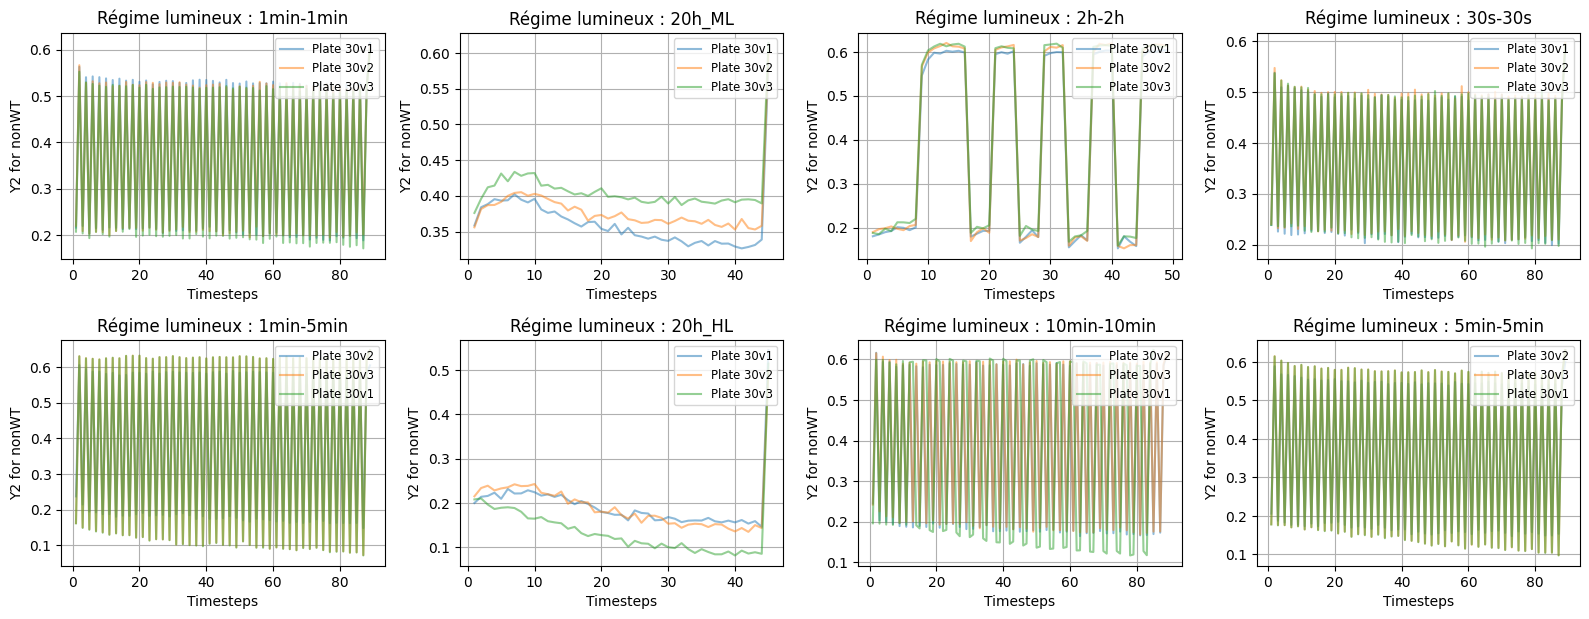

In [12]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')
# Filtrer les colonnes y2_1 à y2_80
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Obtenir les régimes lumineux uniques
light_regimes = data['light_regime'].unique()

# Créer une grille 3x3 pour les graphiques
fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 3x3 grille
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Tracer les graphiques pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith('30'))]    
    # Tracer les courbes pour chaque plaque
    for plate in data_light['plate'].unique():
        data_plate = data_light[ (data_light['mutant_ID'] != 'WT') & (data_light['plate'] == plate) ]
        y2_values = data_plate[y2_columns].mean(axis=0)  # Moyenne des valeurs pour chaque plaque
        ax.plot(range(1, len(y2_columns) + 1), y2_values, label=f'Plate {plate}', alpha = 0.5)
    
    # Ajouter des détails au graphique
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Y2 for nonWT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les axes inutilisés si moins de 9 régimes lumineux
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

In [ ]:
# How many wt are there per plate (for each light regime
import pandas as pd
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/raw_data_phase_1_07_26_2024.csv')
wt_data = data[(data['mutant_ID'].isin(['WT', 'WT CLiP']))]# & (data['start_date'] >= '2024-06-3')]
wt_counts = wt_data.groupby(['plate','light_regime']).agg({'well_id': list, 'mutant_ID': 'size'}).rename(columns={'mutant_ID': 'wt_count'}).reset_index()
wt_counts = wt_counts[['plate','light_regime', 'wt_count', 'well_id']]

is_constant = wt_counts.groupby('plate')['wt_count'].nunique().eq(1).all()
print("Nombre de WT par plaque et par régime lumineux :")
print(wt_counts)

if is_constant:
    print("\nLe nombre de WT est le même pour chaque plaque dans tous les régimes lumineux.")
else:
    print("\nLe nombre de WT varie pour certaines plaques selon les régimes lumineux.")
    
wt_counts.to_csv('wt_counts_per_plate_oldset.csv', index=False)



/tmp/ipykernel_751892/2904843970.py:5: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-02.csv')
/tmp/ipykernel_751892/2904843970.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_plate = data_light[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
/tmp/ipykernel_751892/2904843970.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_plate = data_light[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
/tmp/ipykernel_751892/2904843970.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame inde

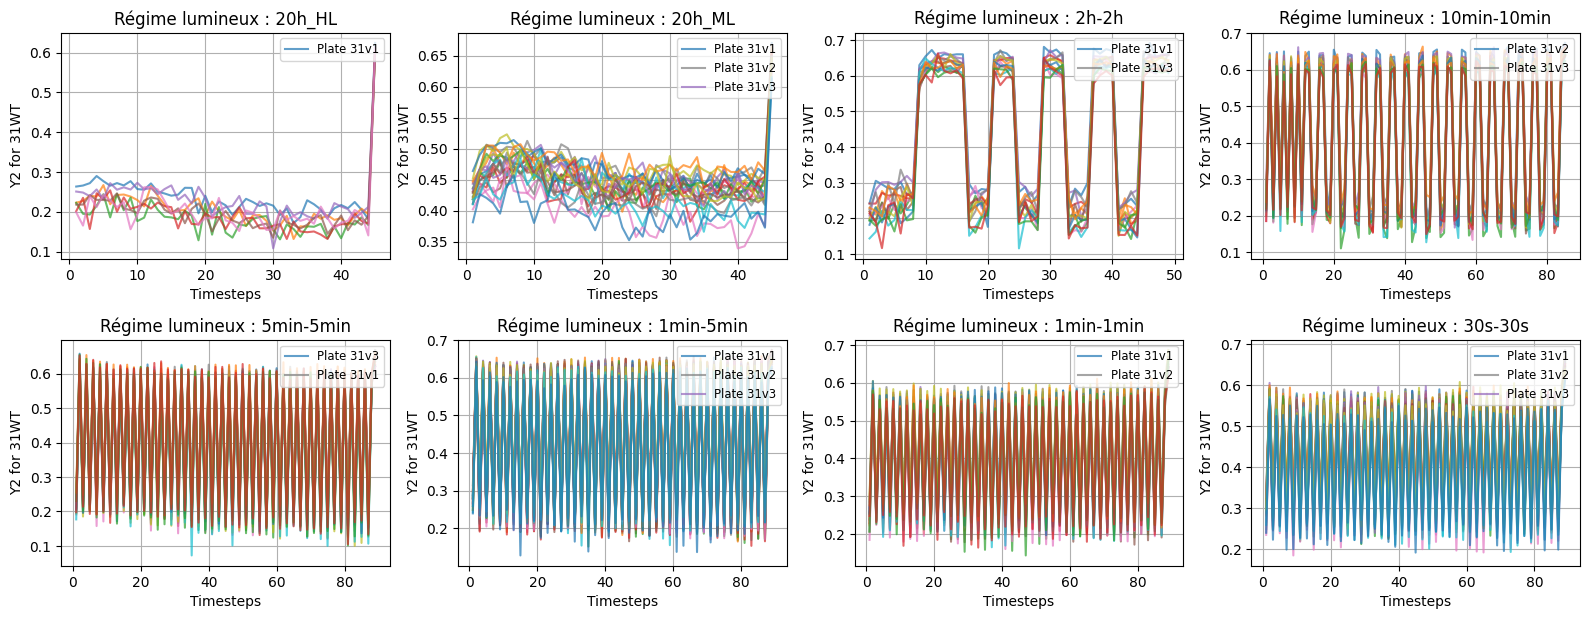

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-02.csv')

# Filtrer les colonnes y2_1 à y2_80
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Obtenir les régimes lumineux uniques
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

# Créer une grille 4x4 pour les graphiques
fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 4x4 grille
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Tracer les graphiques pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith('31'))]  # Filtrer les données pour le régime lumineux actuel

    # Suivi des plaques déjà étiquetées
    labeled_plates = set()
    
    # Tracer les courbes pour chaque plaque
    for plate in data_light['plate'].unique():
        data_plate = data_light[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
        
        # Tracer chaque ligne de données y2 pour la plaque
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values  # Extraire les valeurs y2
            
            # Ajouter un label uniquement si la plaque n'a pas encore été étiquetée
            if plate not in labeled_plates:
                ax.plot(range(1, len(y2_columns) + 1), y2_values, alpha=0.7, label=f'Plate {plate}')
                labeled_plates.add(plate)  # Marquer la plaque comme étiquetée
            else:
                ax.plot(range(1, len(y2_columns) + 1), y2_values, alpha=0.7)  # Pas de label
    
    # Ajouter des détails au graphique
    #axes[i].set_xlim(0, 10)
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Y2 for 31WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les axes inutilisés si moins de 16 régimes lumineux
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

/tmp/ipykernel_760458/4229600913.py:6: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-02.csv')


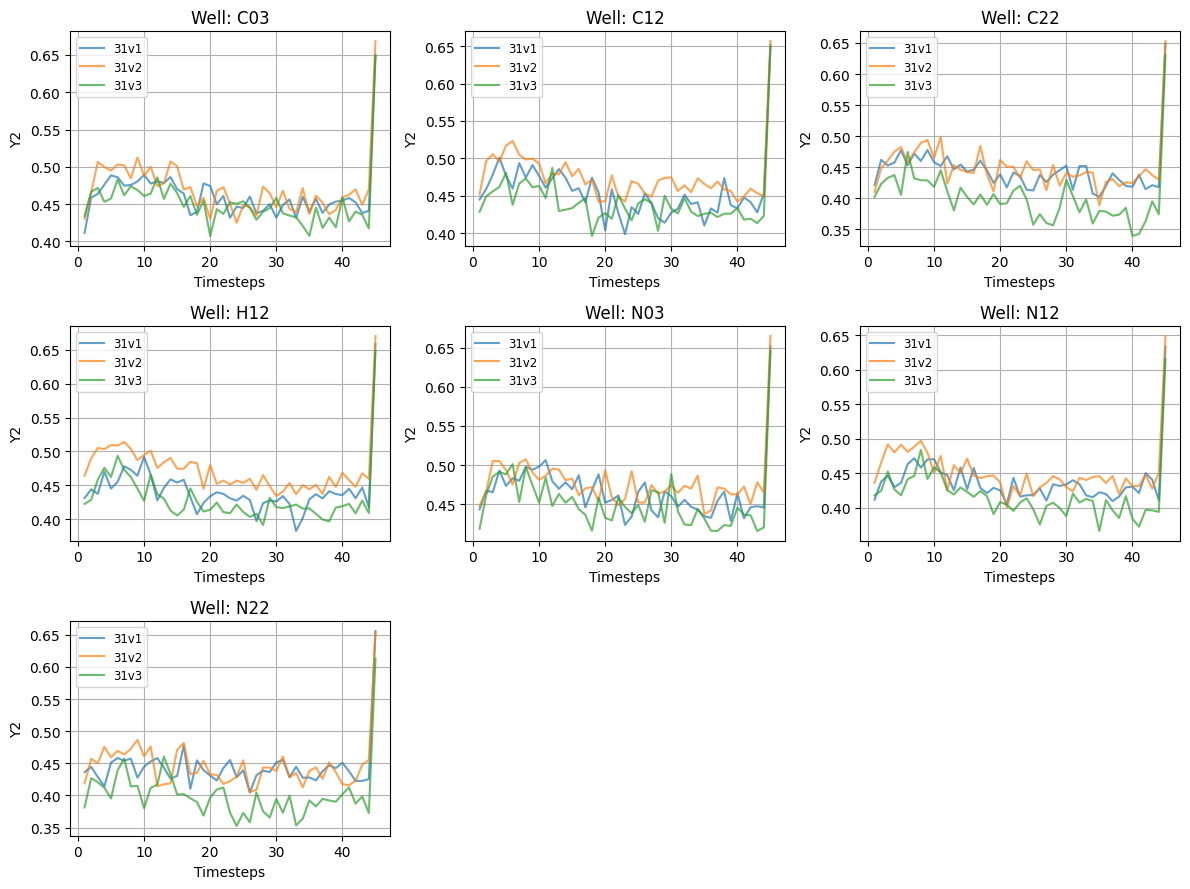

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-02.csv')

# Colonnes y2
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Filtrer les données WT pour les plaques commençant par "31" et le régime lumineux "2h-2h"
filtered = data[
    (data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
    (data['plate'].astype(str).str.startswith('31')) &
    (data['light_regime'] == '20h_ML')
]

# Mapper une couleur différente à chaque valeur unique de 'plate'
unique_plates = filtered['plate'].unique()
import itertools
colors = itertools.cycle(plt.get_cmap('tab10').colors + plt.get_cmap('tab20b').colors + plt.get_cmap('tab20c').colors)
color_map = {plate: next(colors) for plate in unique_plates}


# Unique well_ids
unique_wells = filtered['well_id'].unique()
n = len(unique_wells)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, well_id in enumerate(unique_wells):
    ax = axes[i]
    subset = filtered[filtered['well_id'] == well_id]
    
    for _, row in subset.iterrows():
        y2 = row[y2_columns].values.astype(float)
        plate = row['plate']
        ax.plot(range(1, len(y2_columns) + 1), y2, alpha=0.7, color=color_map[plate], label=plate)

    ax.set_title(f'Well: {well_id}')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Y2')
    ax.grid(True)

    # Ajouter une légende unique par subplot
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), fontsize='small')

# Supprimer les cases vides
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [17]:
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')

/tmp/ipykernel_2210538/1841392368.py:1: DtypeWarning: Columns (330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')


/tmp/ipykernel_236824/2303380204.py:5: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')


['measurement_time_0', 'measurement_time_1', 'measurement_time_2', 'measurement_time_3', 'measurement_time_4', 'measurement_time_5', 'measurement_time_6', 'measurement_time_7', 'measurement_time_8', 'measurement_time_9', 'measurement_time_10', 'measurement_time_11', 'measurement_time_12', 'measurement_time_13', 'measurement_time_14', 'measurement_time_15', 'measurement_time_16', 'measurement_time_17', 'measurement_time_18', 'measurement_time_19', 'measurement_time_20', 'measurement_time_21', 'measurement_time_22', 'measurement_time_23', 'measurement_time_24', 'measurement_time_25', 'measurement_time_26', 'measurement_time_27', 'measurement_time_28', 'measurement_time_29', 'measurement_time_30', 'measurement_time_31', 'measurement_time_32', 'measurement_time_33', 'measurement_time_34', 'measurement_time_35', 'measurement_time_36', 'measurement_time_37', 'measurement_time_38', 'measurement_time_39', 'measurement_time_40', 'measurement_time_41', 'measurement_time_42', 'measurement_time_43

/tmp/ipykernel_236824/2303380204.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_236824/2303380204.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_236824/2303380204.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_236824/2303380204.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(f

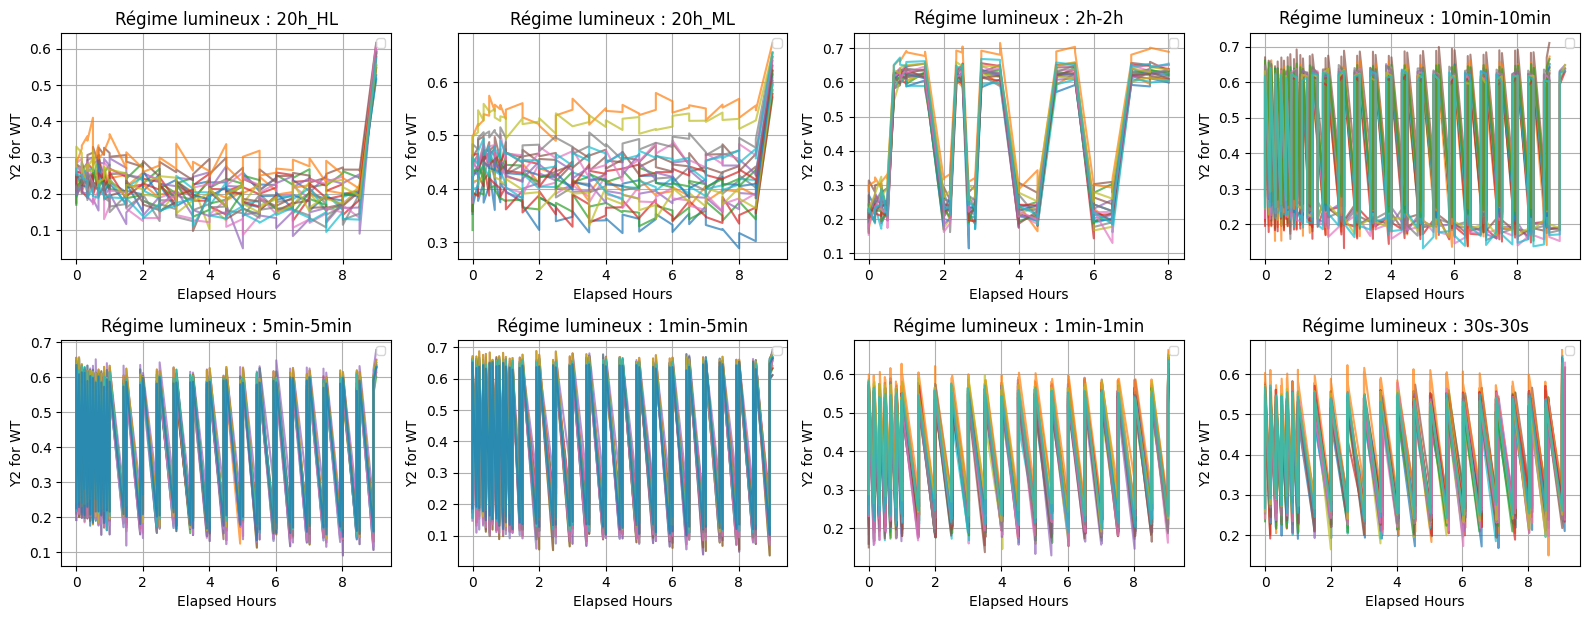

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
print(time_columns)

for col in time_columns:
    data[col] = pd.to_datetime(data[col],format='mixed')

elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)

elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
data = pd.concat([data, elapsed_hours], axis=1)

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 4x4 grille
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Tracer les graphiques pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith('30'))]  # Filtrer les données pour le régime lumineux actuel
    
    # Tracer les courbes pour chaque plaque
    for plate in data_light['plate'].unique():
        data_plate = data_light[(data_light['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
        
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values  # Extraire les valeurs y2
            time_values = row[elapsed_hours.columns].astype(float).values

            valid_indices = ~np.isnan(time_values)
            time_values = time_values[valid_indices]
            y2_values = y2_values[:len(time_values)]  # Assurez-vous que y2_values a la même longueur que time_values
            time_values = time_values[:len(y2_values)]
            ax.plot(time_values, y2_values, alpha=0.7)#, label=f'Plate {plate}')
    
    # Ajouter des détails au graphique
    #axes[i].set_xlim(0, 5)
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2 for WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les axes inutilisés si moins de 16 régimes lumineux
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (276,) and (89,)

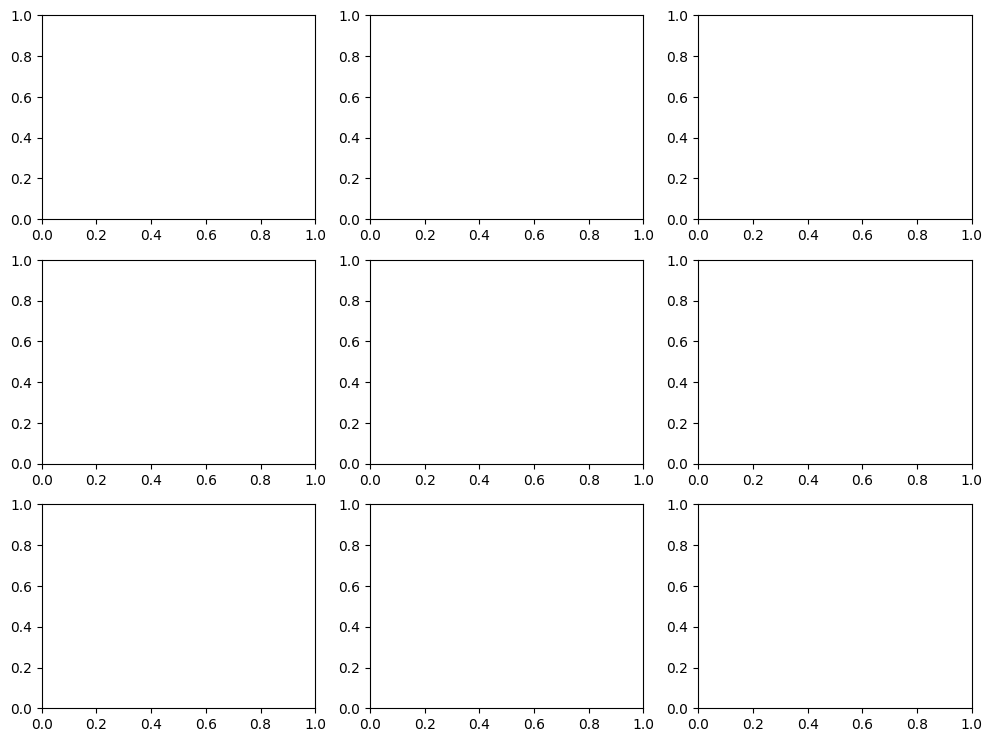

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plate_name='31v1'
# Charger les données
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-30.csv')

# Colonnes y2 et temps
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]

# Convertir les colonnes temps
for col in time_columns:
    data[col] = pd.to_datetime(data[col],format='mixed')

# Ajouter les elapsed_hours
elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
data = pd.concat([data, elapsed_hours], axis=1)

# Filtrer pour la plaque 31v1, WT et régime 20h_HL
filtered = data[
    (data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
    (data['plate'].astype(str).str.startswith(plate_name)) &
    (data['light_regime'] == '20h_HL')
]

# Colonnes elapsed_hours ajoutées
elapsed_cols = elapsed_hours.columns

# Préparer la grille
unique_wells = filtered['well_id'].unique()
n = len(unique_wells)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, well_id in enumerate(unique_wells):
    ax = axes[i]
    subset = filtered[filtered['well_id'] == well_id]
    
    for _, row in subset.iterrows():
        y2 = row[y2_columns].values.astype(float)
        time = row[elapsed_cols].values.astype(float)

        valid = ~np.isnan(time)
        ax.plot(time[valid], y2[:len(time[valid])], alpha=0.7)

    ax.set_title(f'Well: {well_id}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel(f'Y2{ plate_name}')
    ax.grid(True)

# Supprimer les cases vides
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/New_replica_data.csv')

# Filtrer les colonnes de temps de mesure
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]

# Convertir les colonnes de temps en datetime
for col in time_columns:
    data[col] = pd.to_datetime(data[col])

# Obtenir les régimes lumineux uniques
light_regimes = data['light_regime'].unique()

# Créer une figure pour le scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Tracer les points pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith('99'))]  # Filtrer les données pour le régime lumineux actuel
    plate = str(data_light['plate'].unique())  # Obtenir la plaque unique pour ce régime lumineux
    # Extraire les temps de mesure pour ce régime lumineux
    measurement_times = data_light[time_columns].stack().reset_index(drop=True)
    
    # Ajouter les points au graphique
    ax.scatter(measurement_times, [light] * len(measurement_times), alpha=0.6, label=light)

# Ajouter des détails au graphique
#ax.set_xlim(pd.Timestamp('2024-05-19'), pd.Timestamp('2024-12-19'))  # Définir les limites de l'axe des abscisses
ax.set_title(f'Fréquence des mesures pour chaque régime lumineux, plate :{plate}', fontsize=14)
ax.set_xlabel('Temps de mesure', fontsize=12)
ax.set_ylabel('Régime lumineux', fontsize=12)
ax.grid(True)
ax.legend(title='Régimes lumineux', fontsize=10, loc='upper right')
# Ajuster l'affichage
plt.tight_layout()
plt.show()

## Normalization/3

In [47]:
import pandas as pd

# Charger les données
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv')

# Colonnes y2
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Parcourir chaque plaque
for plate in data['plate'].unique():
    for light in data['light_regime'].unique():
        # Filtrer les données pour le régime lumineux et la plaque
        data_light_plate = data[(data['light_regime'] == light) & (data['plate'] == plate)]
        
        # Filtrer les WT
        WT_strains = data_light_plate[data_light_plate['mutant_ID'] == 'WT']
        
        # Vérifier qu'il y a exactement 3 WT
        if len(WT_strains) == 3:
            WT_strains = WT_strains.reset_index(drop=True)
            
            # Séparer les 3 WT
            WT_1 = WT_strains.loc[0].copy()
            WT_2 = WT_strains.loc[1]
            WT_3 = WT_strains.loc[2]
            
            # Calculer la moyenne des valeurs y2 de WT_2 et WT_3
            mean_wt2_wt3 = (WT_2[y2_columns] + WT_3[y2_columns]) / 2
            
            # Normaliser les valeurs y2 de tous les autres mutants
            for idx, row in data_light_plate.iterrows():
                if row['mutant_ID'] != 'WT':  # Exclure les WT
                    for col in y2_columns:
                        data.loc[idx, col] = row[col] - mean_wt2_wt3[col]
            # Soustraire les deux autres WT du premier
            for col in y2_columns:
                WT_1[col] = WT_1[col] - mean_wt2_wt3

            # Mettre à jour la ligne correspondante dans le DataFrame principal
            data.update(WT_1)

# Sauvegarder les résultats si nécessaire
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2024prep_dataset_claireNorm.csv', index=False)

In [1]:
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/New_replica_data.csv')
lengths_list = []  # Utiliser un nom explicite pour la liste
for mut in data['mutant_ID'].unique():
    for col in data[data['mutant_ID'] == mut].columns:
        if col.startswith('mutated_genes'):
            unique_values = data[data['mutant_ID'] == mut][col].unique()
            lengths_list.append(len(unique_values[:]))
            if len(unique_values[:])==3:
                print(f"Mutant {mut} has {len(unique_values)} unique values in {col}: {unique_values}" )
print(lengths_list)

NameError: name 'data' is not defined

In [3]:
from Scripts_Imane import Format_Data
import pandas as pd

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-25.csv')

/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:6: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data_path = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-03-25.csv')
/tmp/ipykernel_1355385/454106571.py:4: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-25.csv')


In [4]:
data_clean = Format_Data.get_format_data(data)


(105708, 726)   light_regime  max_timestep
0    1min-1min            89
1  10min-10min            89
2       20h_HL            45
3       20h_ML            45
4        2h-2h            49
5      30s-30s            89
6    1min-5min            89
7    5min-5min            89
(105708, 726) Colonnes après 1 : Index(['plate', 'measurement', 'start_date', 'light_regime', 'dark_threshold',
       'light_threshold', 'num_frames', 'i', 'j', 'fv_fm',
       ...
       'measurement_time_173', 'measurement_time_174', 'measurement_time_175',
       'measurement_time_176', 'measurement_time_177', 'well_id', 'mutant_ID',
       'feature', 'mutated_genes', 'num_mutations'],
      dtype='object', length=726)
(105708, 374) Colonnes après 2 : Index(['plate', 'measurement', 'start_date', 'light_regime', 'dark_threshold',
       'light_threshold', 'num_frames', 'i', 'j', 'fv_fm',
       ...
       'measurement_time_85', 'measurement_time_86', 'measurement_time_87',
       'measurement_time_88', 'measureme

In [6]:
data_clean.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')

In [5]:
Format_Data.sanity_checks(data_clean)

Earliest start date : 2023-10-12 00:00:00
Most recent start date : 2024-11-27 00:00:00
Light regimes : ['1min-1min' '10min-10min' '20h_HL' '20h_ML' '2h-2h' '30s-30s' '1min-5min'
 '5min-5min']
Number of unique plates : 40
Unique plates : ['99' 2 3 4 5 6 7 9 10 11 12 13 14 15 16 8 18 17 21 22 23 1 20 '30v1'
 '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2' '32v2' '31v3'
 '32v3' '99v1' '33v1' '33v2' '33v3' '99v3']
7 plates have 8 unique light regimes.
21 plates have 6 unique light regimes.
1 plates have 4 unique light regimes.
6 plates have 5 unique light regimes.
5 plates have 7 unique light regimes.


In [6]:
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/New_replica_data.csv')
data=data_clean
lengths_list = []  # Utiliser un nom explicite pour la liste
for mut in data['mutant_ID'].unique():
    for col in data[data['mutant_ID'] == mut].columns:
        if col.startswith('mutated_genes'):
            unique_values = data[data['mutant_ID'] == mut][col].unique()
            lengths_list.append(len(unique_values[:]))
            if len(unique_values[:])==3:
                print(f"Mutant {mut} has {len(unique_values)} unique values in {col}: {unique_values}" )
print(lengths_list)

Mutant LMJ.RY0402.069152 has 3 unique values in mutated_genes: ['Cre17.g722350' 'Cre17.g722400' 'Cre02.g142266']
Mutant LMJ.RY0402.071284 has 3 unique values in mutated_genes: ['Cre01.g048400' 'Cre05.g234643' 'Cre05.g234644']
Mutant LMJ.RY0402.064692 has 3 unique values in mutated_genes: ['Cre14.g634322' 'Cre14.g634365' 'Cre14.g625150']
Mutant LMJ.RY0402.077271 has 3 unique values in mutated_genes: ['Cre08.g373366' 'Cre08.g373367' 'Cre14.g616000']
Mutant LMJ.RY0402.069113 has 3 unique values in mutated_genes: ['Cre08.g372100' 'Cre08.g372150' 'Cre06.g283850']
Mutant LMJ.RY0402.084462 has 3 unique values in mutated_genes: ['Cre08.g372100' 'Cre08.g372150' 'Cre07.g329500']
Mutant LMJ.RY0402.085477 has 3 unique values in mutated_genes: ['Cre14.g613134' 'Cre02.g077700' 'Cre02.g077750']
Mutant LMJ.RY0402.085616 has 3 unique values in mutated_genes: ['Cre11.g467658' 'Cre01.g046850' 'Cre01.g046950']
Mutant LMJ.RY0402.092547 has 3 unique values in mutated_genes: ['Cre11.g467741' 'Cre10.g436150' 

In [ ]:
# Vérifier la longueur des éléments dans mutated_genes
gene_lengths = data['mutated_genes'].apply(lambda x: len([g.strip() for g in str(x).replace('&', ',').split(',') if g.strip()]))

print(f"Minimum number of genes per row: {gene_lengths.min()}")
print(f"Maximum number of genes per row: {gene_lengths.max()}")


Minimum number of genes per row: 1
Maximum number of genes per row: 1


/tmp/ipykernel_1619513/303265558.py:3: DtypeWarning: Columns (1,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,372,373) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')


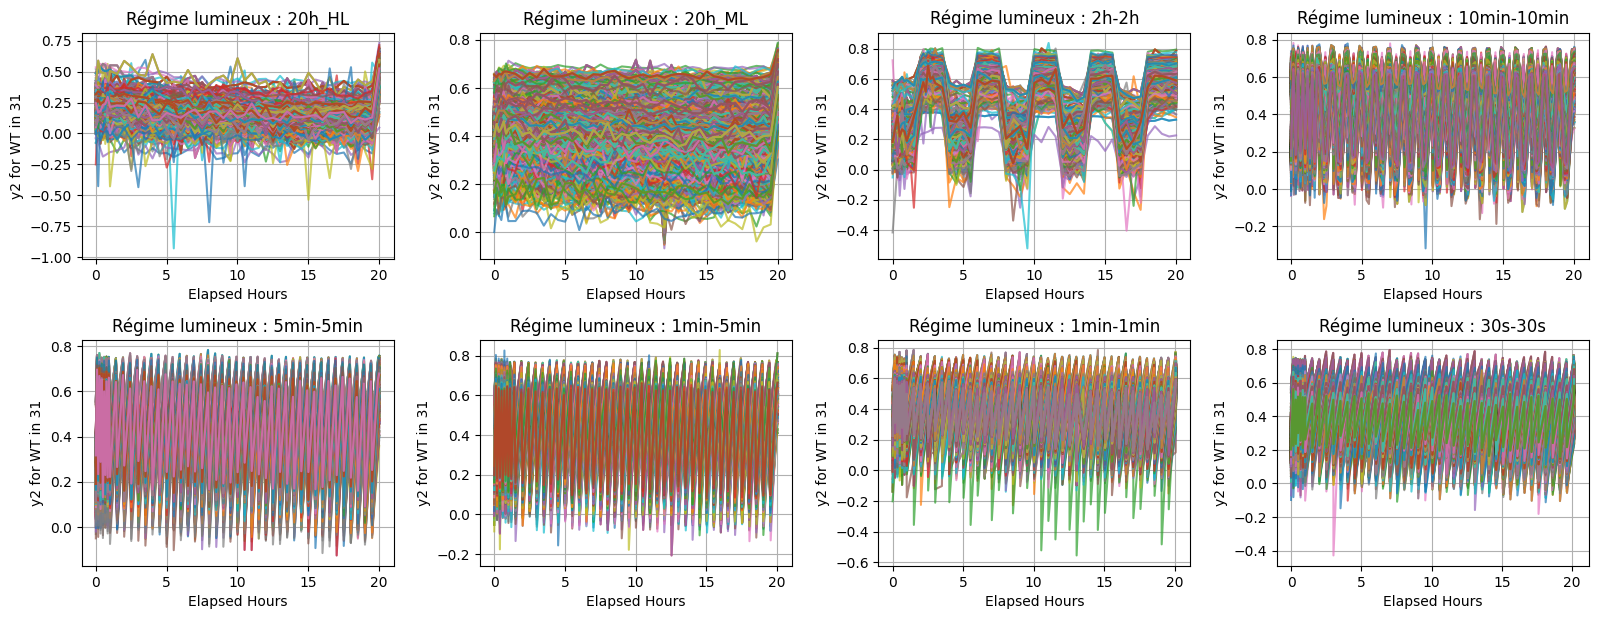

In [3]:
from Scripts_Imane import Plots
import pandas as pd 
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')
Plots.plot_raw_y(data, ts = 'y2', which_plate = '31', mutant = 'WT')

In [ ]:
from Scripts_Imane import Plots
import pandas as pd 
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')
Plots.plot_raw_y(data, ts = 'y2', which_plate = '30', mutant = 'WT')

/tmp/ipykernel_1621349/2784945739.py:3: DtypeWarning: Columns (1,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,372,373) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fe03bda9fd0>>
Traceback (most recent call last):
  File "/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
